<a href="https://colab.research.google.com/github/gagnagaman/Tziperman/blob/main/temperature_workshop_colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <font color=green> Global Warming Science</font>
#### https://courses.seas.harvard.edu/climate/eli/Courses/EPS101/

# Temperature

### <font color=red> Please use the template below to answer the workshop questions. "XX" indicates places where you need to complete/write code or add a discussion.</font>

### your name:

#### <font color=red> If not using FAS on-demand Jupyter server: Start by installing a package for plotting maps: cartopy.
    
**Option 1:** from the Anaconda Navigator: click environments -> search, toggle to "uninstalled", mark and click install.<br>
**Option 2:** from a terminal:<br>
conda install cartopy<br>
or if this does not work<br>
pip install cartopy

In [2]:
!pip install cartopy


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 40.9 MB/s eta 0:00:00


In [3]:
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
# cortopy allows to plot data over maps in various spherical prjections"
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.feature import NaturalEarthFeature
from cartopy import config
from mpl_toolkits.axes_grid1 import make_axes_locatable
from scipy.integrate import solve_ivp
from scipy import optimize
from scipy.stats import linregress

In [5]:
import requests

url="https://raw.githubusercontent.com/gagnagaman/Tziperman/main/temperature_variables.pickle"

# Download the pickle file from the URL
response = requests.get(url)
response.raise_for_status() # Raise an exception for bad status codes
with open('temperature_variables.pickle', 'wb') as f:
    f.write(response.content)

# load data from pickle file:
# ---------------------------
with open('./temperature_variables.pickle', 'rb') as file:
        d = pickle.load(file)
        # print information about each extracted variable:
        for key in list(d.keys()):
            print("extracting pickled variable: name=", key, "; size=", d[key].shape)
            #print("; type=",type(d[key]))
        globals().update(d)

extracting pickled variable: name= RCP85_zonally_avg_T_2010 ; size= (23, 90)
extracting pickled variable: name= RCP85_zonally_avg_T_2100 ; size= (23, 90)
extracting pickled variable: name= RCP85_zonally_avg_T_height ; size= (23,)
extracting pickled variable: name= RCP85_zonally_avg_T_lat ; size= (90,)
extracting pickled variable: name= hockeystick_annual_temperature_anomaly_timeseries ; size= (2, 1507)
extracting pickled variable: name= rcp26_global_sat_anomaly_timeseries ; size= (2, 95)
extracting pickled variable: name= rcp45_global_sat_anomaly_timeseries ; size= (2, 295)
extracting pickled variable: name= rcp85_first_5yr_sat_map ; size= (90, 144)
extracting pickled variable: name= rcp85_global_sat_anomaly_timeseries ; size= (2, 95)
extracting pickled variable: name= rcp85_last_5yr_sat_map ; size= (90, 144)
extracting pickled variable: name= rcp85_sat_map_axes ; size= (2,)
extracting pickled variable: name= sat_control_series_GFDL ; size= (100,)
extracting pickled variable: name= sat

In [13]:
import pandas as pd

# Create a dictionary to store DataFrames
dataframes = {}

# Iterate through the loaded data and create DataFrames
for key, value in d.items():
    try:
        # Attempt to create a DataFrame, handling potential shape issues
        if isinstance(value, np.ndarray):
            if value.ndim == 1:
                dataframes[key] = pd.DataFrame(value, columns=[key])
            elif value.ndim == 2:
                # For 2D arrays, create and then transpose
                df = pd.DataFrame(value)
                dataframes[key] = df.T # Transpose the DataFrame
            else:
                print(f"Skipping variable '{key}' with shape {value.shape} as it's not 1D or 2D.")
        else:
            print(f"Skipping variable '{key}' as it is not a numpy array.")
    except Exception as e:
        print(f"Could not create DataFrame for '{key}': {e}")

# You can access the DataFrames like this:
# hockeystick_df = dataframes['hockeystick_annual_temperature_anomaly_timeseries']
# rcp85_df = dataframes['rcp85_global_sat_anomaly_timeseries']

# Displaying the keys of the dataframes dictionary to show what was created
print("Created DataFrames for the following variables:")
print(dataframes.keys())

Created DataFrames for the following variables:
dict_keys(['RCP85_zonally_avg_T_2010', 'RCP85_zonally_avg_T_2100', 'RCP85_zonally_avg_T_height', 'RCP85_zonally_avg_T_lat', 'hockeystick_annual_temperature_anomaly_timeseries', 'rcp26_global_sat_anomaly_timeseries', 'rcp45_global_sat_anomaly_timeseries', 'rcp85_first_5yr_sat_map', 'rcp85_global_sat_anomaly_timeseries', 'rcp85_last_5yr_sat_map', 'rcp85_sat_map_axes', 'sat_control_series_GFDL', 'sat_obs_GISS_annual_anomaly_timeseries'])


In [18]:
rcp85_df=dataframes['rcp85_global_sat_anomaly_timeseries']
rcp85_df.rename(columns={0: 'Year', 1: 'SAT'}, inplace=True)
display(rcp85_df.head())

,Year,SAT
0,2006.0,1.000768
1,2007.0,0.874393
2,2008.0,0.996856
3,2009.0,1.029536
4,2010.0,0.868448


from matplotlib import pyplot as plt
_df_0['Year'].plot(kind='hist', bins=20, title='Year')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_1['SAT'].plot(kind='hist', bins=20, title='SAT')
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
_df_2.plot(kind='scatter', x='Year', y='SAT', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  xs = series['Year']
  ys = series['SAT']
  
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_3.sort_values('Year', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Year')
_ = plt.ylabel('SAT')

from matplotlib import pyplot as plt
import seaborn as sns
def _plot_series(series, series_name, series_index=0):
  palette = list(sns.palettes.mpl_palette('Dark2'))
  counted = (series['Year']
                .value_counts()
              .reset_index(name='counts')
              .rename({'index': 'Year'}, axis=1)
              .sort_values('Year', ascending=True))
  xs = counted['Year']
  ys = counted['counts']
  plt.plot(xs, ys, label=series_name, color=palette[series_index % len(palette)])

fig, ax = plt.subplots(figsize=(10, 5.2), layout='constrained')
df_sorted = _df_4.sort_values('Year', ascending=True)
_plot_series(df_sorted, '')
sns.despine(fig=fig, ax=ax)
plt.xlabel('Year')
_ = plt.ylabel('count()')

from matplotlib import pyplot as plt
_df_5['Year'].plot(kind='line', figsize=(8, 4), title='Year')
plt.gca().spines[['top', 'right']].set_visible(False)

from matplotlib import pyplot as plt
_df_6['SAT'].plot(kind='line', figsize=(8, 4), title='SAT')
plt.gca().spines[['top', 'right']].set_visible(False)

<Axes: xlabel='Year', ylabel='SAT'>

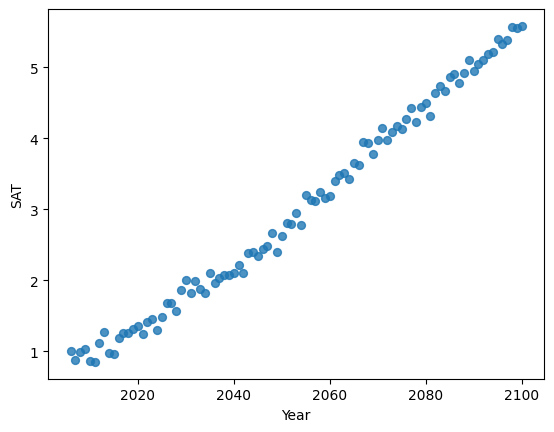

In [20]:
from matplotlib import pyplot as plt
rcp85_df.plot(kind='scatter', y='SAT', x='Year', s=32, alpha=.8)

## Explanation of input variables:

RCP85_zonally_avg_T_2010: zonally-averaged atmospheric temperature at 2010 as a function of height and latitude.

RCP85_zonally_avg_T_2100: same for an RCP8.5 projection at 2100

RCP85_zonally_avg_T_height: height coordinate for previous two variables

RCP85_zonally_avg_T_lat: latitude coordinate for above two variables

hockeystick_annual_temperature_anomaly_timeseries

**In the followings, SAT=Surface air temperature. The variables ending with "_timeseries" include two arrays, the time axis and SAT anomaly time series:**

Three Projections:

rcp26_global_sat_anomaly_timeseries, rcp45_global_sat_anomaly_timeseries,
rcp85_global_sat_anomaly_timeseries,

and observations:

sat_obs_GISS_annual_anomaly_timeseries

**Maps of temperature as a function of latitude and longitude and the corresponding axes:**

rcp85_last_5yr_sat_map,
rcp85_first_5yr_sat_map,
rcp85_sat_map_axes

**A time series of 100 years from a "control" climate model run, with fixed pre-industrial CO2:**

sat_control_series_GFDL

## 1) Characterize the warming, historical and future projections:

#### 1a) “Hockey stick curve”: Line plot of global-mean, annual-mean temperature anomaly as function of time, for observations continued by RCP8.5 and RCP2.6 scenarios.

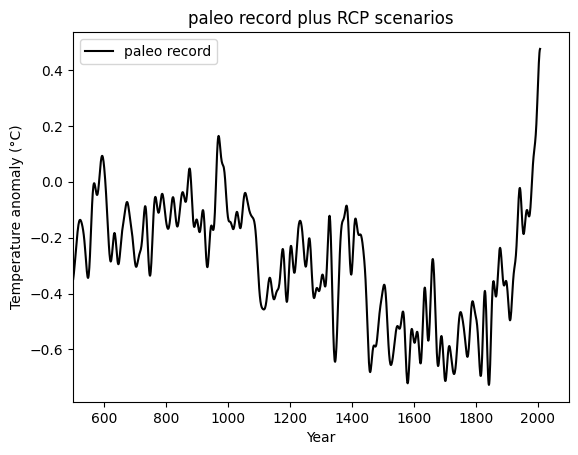

In [21]:
"""
Plot the paleo global temperature record followed by three RCP scenarios.
"""
# Rename variables for convenience:
historic=hockeystick_annual_temperature_anomaly_timeseries
rcp26=rcp26_global_sat_anomaly_timeseries
rcp45=rcp45_global_sat_anomaly_timeseries
rcp85=rcp85_global_sat_anomaly_timeseries

# plot:
plt.plot(historic[0,:], historic[1,:], "k",label="paleo record")
# plot rcp26, rcp45, rcp85 XX

# labels and titles:
plt.xlim(500,2100)
plt.ylabel("Temperature anomaly (°C)")
plt.xlabel("Year")
plt.title("paleo record plus RCP scenarios")
plt.legend()
plt.show()


#### 1b) Spatial distribution of warming: Contour the temperature at the beginning of the 21st century, end, and the change over the 21st century, according to the RCP8.5 scenario.

In [ ]:
# Load the plot axes:
longitude = rcp85_sat_map_axes[1]
latitude = rcp85_sat_map_axes[0]
contour_levels=np.arange(250,314,1) # for temperature plots

# plot first 5 year temperature:
# -------------------------------
fig=plt.figure(figsize=(12,6))
ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=0.0, globe=None))
ax.set_extent([-180, 180, -90, 90], crs=ccrs.PlateCarree())
ax.coastlines(resolution='110m')
ax.gridlines()

# plot contours:
c=plt.contourf(longitude, latitude, rcp85_first_5yr_sat_map,levels=contour_levels)
# draw the colorbar
clb=plt.colorbar(c, shrink=0.85, pad=0.02)
# add title/ labels:
plt.xlabel('Longitude')
plt.ylabel('Latitude')
clb.set_label('Temperature (K)')
plt.title('Temperature during 1st 5 years of RCP 8.5')
plt.show()

# plot last 5 year temperature:
# -------------------------------
contour_levels=XX # for temperature plots
XX
c=plt.contourf(XX, XX, XX,levels=contour_levels)
XX

# plot the warming:
# -----------------
# loading data from file
warming_sat_map_data = rcp85_last_5yr_sat_map-rcp85_first_5yr_sat_map
# use cmap='bwr' in the contourf call,
# and symmetric contour levels centered around zero:
contour_levels_warming=np.arange(XX)
XX
c=plt.contourf(XX, XX, XX,levels=contour_levels_warming)
XX

#### 1c) Polar amplification: Plot the zonally-averaged warming vs latitude for the RCP8.5 scenario.

In [ ]:
# calcuate zonal mean warming:
# zonal_mean_rcp85_warming=XX use np.mean to calculate it, averaging over longitude

# a plot:
plt.plot(zonal_mean_rcp85_warming,latitude)
plt.xlabel('XX')
plt.ylabel('XX')
plt.title('XX')
# show the plot
plt.show()

## 2) Hiatus:

#### 2a) Plot the global-mean, annual-mean control-run temperature variability with and without an added linear trend of 1 °C/century.

In [ ]:
# --------------------------------------------------------------
# plot a monthly time series of global mean SATs from the control
# dataset of the GFDL model with and without added linear trend,
# to demonstrate how "hiatuses" arise from variability plus a
# warming trend.
# [thanks to Yonathan Vardi]
# --------------------------------------------------------------

fig = plt.figure(figsize=(12,6))

sat_control_series = sat_control_series_GFDL
# The time axis for control time series:
control_years = np.arange(1, 1+len(sat_control_series))
# generate a linear temperature trend of 0.01 degree per year
control_linear_trend = XX
# combine the trend and the series
series_with_trend = control_linear_trend + sat_control_series

#plot SAT control run and SAT control run plus linear trend
plt.subplot(1, 2, 1)
plt.plot(control_years, XX, ":")
plt.plot(control_years, XX)

plt.ylabel("Temperature (°C)")
plt.xlabel("years")
plt.title("Control run + Linear Trend")

# plot for comparison the global temperature record from the last 100 years:
# --------------------------------------------------------------------------
plt.subplot(1, 2, 2)
obs=sat_obs_GISS_annual_anomaly_timeseries
print("note that the array obs contains both the time axis as obs[0,:] \nand the data as obs[1,:]. its shape is:",obs.shape)
plt.plot(XX)
plt.ylabel("Temperature (°C)")
plt.xlabel("years")
plt.title("The instrumental record")

#show the plot
plt.tight_layout()
plt.show()


#### (b) Plot the observed global temperature anomaly starting 1970 to the last year of data. Fit a linear trend to 1970-1998. Extend the plot of the linear fit through the last year of data. Comment on whether the data post the supposed 1998--2013 “hiatus” period support the idea that global warming ceased in 1998.

In [ ]:
obs=sat_obs_GISS_annual_anomaly_timeseries
x=obs[0,:]
y=obs[1,:]

xfit=x[np.logical_and(x>=1970,x<1998)]
yfit=XX
fit=linregress(xfit, yfit)
slope=fit.slope;
intercept=fit.intercept;
fitted_line_until_1998=XX
fitted_line_to_end_of_data=XX

fig = plt.figure(figsize=(5,2.5),dpi=300)
plt.plot(x,y,color="r",linewidth=1,label="Observed GMST")
plt.plot(XX,label="Fit until 1998",linewidth=3)
plt.plot(XX,label="Fit continued",linewidth=1)
plt.ylabel("Temperature anomaly (°C)")
plt.xlabel("Year")
plt.xlim(1969,2020)
plt.ylim(XX)
plt.legend()
plt.grid(lw=0.25)

Comment: XX

## 3) Equilibrium climate sensitivity:

The current radiative forcing anomaly due to anthropogenic emissions is 2.3 Watts/m$^{2}$, the current global-mean surface warming is 1C. Assume 50\% of the radiative forcing heat flux anomaly currently goes into the ocean. Estimate the equilibrium warming at a double-preindustrial CO$_2$ concentration ($2\times280$ ppm), assuming that this corresponds to a radiative forcing of 4 Watts/m$^{2}$.

In [ ]:
Delta_F=XX   # radiative forcing now
Delta_Q=XX   # heat absorbed by the ocean now
Delta_F2x=XX # radiative forcing at 2xCO2
Delta_T=XX   # warming now
Delta_T2x=XX # warming for 2xCO2
print("The expected equilibrium (steady-state) warming is ",Delta_T2x)

## 4) Transient Climate sensitivity and the role of the ocean

Solve equations 3.3 and plot  $\Delta{}T_{\mathrm{deep}}$ and  $\Delta{}T_{\mathrm{surface}}$ for $t=0,\ldots,5000$ years, for $H=40$ m and for $H=4000$ m. Show directly from the equations that the steady state solution is consistent with the plotted results. Explain the role of the ocean heat capacity in the response to global warming.

In [ ]:
# solve the above two ordinary differential equations and plot, for a deep
# and a shallow ocean.

########################################################################
# functions
########################################################################
# Right hand side to be integrated:
def right_hand_side(t, T, depth):
    T_atm=T[0]
    T_ocn=T[1]
    lambda_LW = 4/3      #longwave radiative cooling coefficient
    c_atm = c_p * rho_w * 50 #specific heat of upper ocean and atmosphere
    dF = 4  #radiative forcing
    c_ocn = c_p * rho_w * depth  #the specific heat of the ocean
    gamma = 1   #strength of coupling between surface and deep
    dT_atm_dt = ((dF - lambda_LW*T_atm) - gamma*(T_atm-T_ocn))/c_atm
    dT_ocn_dt = gamma*(T_atm-T_ocn)/c_ocn
    return [dT_atm_dt, dT_ocn_dt]

def solve_ODE(depth):
    """
    Solve the ODE for a given ocean depth
    Input: Depth of the ocean.
    Output: ocean temperature time series, atmospheric temperature
            time series, and the time axis.
    """
    y0=T0
    tspan=(times_save[0],times_save[-1])
    sol = solve_ivp(fun=lambda t,T: right_hand_side(t,T,depth) \
                ,vectorized=False,y0=T0,t_span=tspan,t_eval=times_save)
    time_array=sol.t
    T_atm_array=sol.y[0,:]
    T_ocn_array=sol.y[1,:]

    return T_ocn_array,T_atm_array, time_array/YEAR


########################################################################
# Main program
########################################################################

# set parameters:
# ---------------
YEAR = 31536000 # A year in seconds
YEARS_TO_RUN = 5000
T0, time_start = (0.0,0.0), 0.0 # initial values for (T_ocn, T_atm) and time:
time_end = YEAR * YEARS_TO_RUN #the maximum value of time
times_save = np.arange(time_start,time_end,YEAR/12) # times for saving ODE solution
N=len(times_save) #the number of points calculated
c_p = 4005 # J/kg, specific heat of seawater
rho_w = 1023.6 # kg/m^3, density of seawater


# solve for temperature in both cases:
# ------------------------------------
T_ocn_array_deep,   T_atm_array_deep,   time_array_deep    = solve_ODE(depth=4000)
T_ocn_array_shallow,T_atm_array_shallow,time_array_shallow = solve_ODE(depth=40)


# print final results at 10 years and at steady state:
# ----------------------------------------------------
print("The temperatures of the atmosphere/ ocean for the case of a shallow ocean are:")
# print the state at 10 years:
print("year=",time_array_shallow[XX],",T_ocn=",T_ocn_array_shallow[XX],",T_atm=",T_atm_array_shallow[XX])
# print the state at steady state (last time calculated):
print("year=",time_array_shallow[XX],",T_ocn=",T_ocn_array_shallow[XX],",T_atm=",T_atm_array_shallow[-1])
print("The temperatures of the atmosphere/ ocean for the case of a deep ocean are:")
# same as above but for the deep ocean, at 10 years and at a steady state:
XX

# plot solution time series for a shallow ocean for the first 200 years:
# ----------------------------------------------------------------------
plt.figure(figsize=(8,4));
plt.subplot(3,1,1)
plt.plot(time_array_shallow, T_atm_array_shallow, "--", color='SkyBlue',
         label="Surface Temperature (40m ocean)")
plt.plot(time_array_shallow, T_ocn_array_shallow, "--", color='MidnightBlue',
         label="Ocean Temperature (40m ocean)")
plt.ylabel('∆T (deg C)')
plt.xlabel('t (years)')
plt.title('Atm/ Ocean temperature anomalies given a sudden 2x CO₂ increase')
plt.legend(loc='lower right')
plt.xlim([0,200])

# plot solution time series for a deep ocean for the first 200 years:
# -------------------------------------------------------------------
plt.subplot(3,1,2)
XX
plt.xlim([0,200])

# plot solution time series for a deep ocean for the whole 5000 years period:
# ---------------------------------------------------------------------------
plt.subplot(3,1,3)
XX


writing the equations
\begin{align}
  C_{\mathrm{surface}} \frac{d \Delta{}T_{\mathrm{surface}}}{d t}
  &=\Delta F_{2\times}-\lambda_{LW} \Delta{}T_{\mathrm{surface}}-\gamma\left(\Delta{}T_{\mathrm{surface}}-\Delta{}T_{\mathrm{deep}}\right)
  \nonumber \\
  C_{\mathrm{deep}} \frac{d \Delta{}T_{\mathrm{deep}}}{d t}&=\gamma\left(\Delta{}T_{\mathrm{surface}}-\Delta{}T_{\mathrm{deep}}\right).
\end{align}

at a steady state

XX

The second one tells us that $\Delta{}T_{\mathrm{surface}}=\Delta{}T_{\mathrm{deep}}$, and substituting that in the first equation we find

XX

as requested. Evaluating the solution,

Delta_T=XX

Evaluating the solution numerically,

Delta_T=XX degrees

#### DISCUSSION:
based on this, the role of the ocean heat capacity is XX

## 5) Polar amplification

#### a) Planck Feedback:

(i) Consider $F=\epsilon\sigma{}T^4$, letting $\epsilon=0.6$, calculate the warming $\Delta{}T$ due to an increase in radiative forcing of $\Delta{}F=4$ Watt/m$^2$, if $T=-10^\circ$C, and then if $T=30^\circ$C. (Hint: it is easier to calculate $\Delta F$ from $T$ and $\Delta T$ for different values of $\Delta T$).  

(ii) Calculate also $dF/dT$ for these two temperatures by taking a derivative of the black body radiation law.

In [ ]:
# for T = -10 C:
T=XX
# Try different DeltaT until you find one for which the change in
# radiation (change in RHS of F=\epsilon\sigma{}T^4) is equal to DeltaF:
DeltaT=XX
epsilon=0.6
sigma=5.67e-8
# define RHS to be epsilon*sigma*T^4 at the warmer temperature minus at the original temperature:
print("DeltaF=4, T=",T,", DeltaT=",DeltaT,",RHS=",XX)
print("dF/dT=",XX)

# for T = 30 C:
XX
print("dF/dT=",XX)



#### (iii) Plot $\Delta T$ as a function of $T$, in response to a constant $\Delta F$ radiative forcing based on the linearization $\Delta F=4\sigma T^3 \Delta T$.

In [ ]:
# plot delta T as function of T, in response to a constant deltaF readiative forcing.
# based on the linearization DeltaF=4*sigma*T^3*DeltaT
T=np.arange(240,311,1)
DeltaF=4
DeltaT=XX

fig=plt.figure(figsize=(4,3),dpi=200)
plt.plot(XX)

### 5b) Optional extra credit: Tropical lapse rate feedback:

Calculate the temperature profile of a saturated air parcel being raised in the tropical atmosphere, with initial surface temperatures of 25 °C and 27 °C, and the difference between the profiles. Discuss your results.

In [ ]:
# PHYSICAL CONSTANTS
PZERO   = 101325.0 # sea-level pressure, N/sq.m
g       = 9.81     # gravity
R_water = 461.52   # gas constant J/kg/K
R_dry   = 287      # gas constant J/kg/K
cp_dry  = 1005     # J/kg/K
L       = 24.93e5  # latent heat J/kg (vaporization at t.p.)


def q_sat(T,P):
    """
    Calculate saturation specific humidity (gr water vapor per gram moist air).
    inputs:
    T: temperature, in Kelvin
    P: pressure, in mb
    """
    R_v = 461 # Gas constant for moist air = 461 J/(kg*K)
    R_d = 287 # Gas constant 287 J K^-1 kg^-1
    TT = T-273.15 # Kelvin to Celsius
    # Saturation water vapor pressure (mb) from Emanuel 4.4.14 p 116-117:
    ew = 6.112*np.exp((17.67 * TT) / (TT + 243.5))
    # saturation mixing ratio (gr water vapor per gram dry air):
    rw = (R_d / R_v) * ew / (P - ew)
    # saturation specific humidity (gr water vapor per gram moist air):
    qw = rw / (1 + rw)
    return qw

## Calculate moist adiabatic temperature profiles for two surface temperatures

# Define the height coordinates, calculate background pressure and temperature profiles.
z = np.linspace(0,12,1001) # z in km
p = np.zeros(np.shape(z))  # initialize P array
#T_env = np.zeros(np.shape(z))  # initialize T array

# Assume isothermal atmosphere to calculate the atmospheric pressure at z:
T_const = 273.15
p = PZERO*np.exp(-g*z/R_dry/T_const)/100 # convert pressure to mb for q_sat

def MSE_conservation(T,P,z,MSE_s,q_s):
    """ This function is called by a root finder to calculate
    the temperature of a rising parcel. it is equal to zero when
    MSE conservation is satisfied.
    """
    qsat=q_sat(T,P)
    # the root finder is looking for the value of T for which the following is zero:
    ans = cp_dry*T+L*min(q_s,qsat)+g*z-MSE_s
    return(ans)


def calc_moist_adiabatic_T_profile(p_s,T_s,z_s,RH_s):
    """ Use conservation of MSE to calculate the temperature of a
        adiabatically lifted moist parcel.
    """

    q_s=RH_s*q_sat(T_s,p_s)
    # initial MSE at surface, to be conserved by rising air parcel:
    MSE_s = cp_dry*T_s+g*z_s+L*q_s
    T_parcel = np.zeros(np.shape(z))

    T_parcel[0] = T_s
    for i in range(1,len(z)):
        sol = optimize.root(MSE_conservation, T_parcel[i-1], args=(p[i],z[i]*1000,MSE_s,q_s))
        T_parcel[i] = np.ndarray.item(sol.x)

    return T_parcel


# initiaize figure and two subplots for temperature and relative humidity:
plt.figure(figsize=(8,6),dpi=200)

plt.subplot(1,2,1)
# calculate and plot first convcection profile:
p0 = p[0]
t0 = 273.15 + 25 #t[0]
z0 = z[0]
RH = 1.0
T_profile1 = calc_moist_adiabatic_T_profile(p0,t0,z0,RH)
plt.plot(T_profile1,z,label="$T_s=25$ °C")

# calculate and plot second convcection profile starting with Ts=27C:
# XX
#XX plt.plot(T_profile2,z,label="$T_s=27$")


# labels and title for first subplot:
plt.legend()
plt.xlabel('$T$ (K)')
plt.ylabel('$z$ (km)')
plt.title('Temperature');

# plot temperature difference as function of height:
plt.subplot(1,2,2)
plt.plot(XX,z)
plt.xlabel('$\Delta T$ (K)')
plt.ylabel('$z$ (km)')
plt.title('Warming');

plt.tight_layout()

discussion:

XX

#### 5c) Optional extra credit: Lapse rate feedback:

Assume the radiative forcing due to greenhouse gasses is $\Delta F=8.5$ W/m$^2$, and that the radiation balance at the emission level is given by the linearized expression $\Delta F=\lambda_{LW}\Delta T_e$. Further assume that the lapse rate feedbacks are such that the tropical (Arctic) warming at the emission height is a factor $X$ ($1/X$) times that at the surface. What should $X$ and $\lambda_{LW}$ be to explain a surface Arctic amplification of 10K, such that the averaged surface warming in the two areas is 6K?

#### Solution:

XX

# 6) Stratospheric cooling

6a) Plot the profiles of the temperature averaged zonally and between latitudes of 30$^\circ$N and 50$^\circ$N before and after a projected RCP8.5 warming. Contour the zonally averaged temperature change over the 21st century in the RCP8.5 scenario as a function of latitude and height in the troposphere and stratosphere.

In [ ]:
lat=RCP85_zonally_avg_T_lat
height=RCP85_zonally_avg_T_height

# calculate averaged vertical temperature profiles in midlatitudes:
TA1_midlats=RCP85_zonally_avg_T_2010[:,np.logical_and(lat>30,lat<50)]
TA2_midlats=RCP85_zonally_avg_T_2100[:,np.logical_and(lat>30,lat<50)]
TA1_midlats_avg=np.nanmean(TA1_midlats,1)
TA2_midlats_avg=np.nanmean(TA2_midlats,1)

fig=plt.figure(figsize=(7,3),dpi=200)
plt.clf()

plt.subplot(1,2,1)
# plot a vertical profile of the temperature before and after global warming:
plt.plot(XX,XX,color="b",label="2006–2010")
plt.plot(XX,XX,color="r",label="2096–2100")
plt.xlabel('Temperature (K)')
plt.ylim([0,50])
plt.legend()

plt.subplot(1,2,2)
# plot latitude-hjeight section of warming:
RCP85_zonally_avg_warming=RCP85_zonally_avg_T_2100-RCP85_zonally_avg_T_2010
# contour latitude-height section of warming:
levels = np.arange(-16,17,1)
plt.contourf(XX, XX, XX, levels=levels)
#plt.gca().invert_yaxis()
plt.set_cmap('bwr')
hcb=plt.colorbar()
plt.xlabel('Latitude')
plt.ylabel('Height (km)')
plt.ylim([0,50])

plt.tight_layout()
plt.show()

6b) Calculate the expected tropospheric warming and stratospheric cooling as the tropospheric and stratospheric emissivities change from $\epsilon_{tro}=0.55$ and $\epsilon_{str}=0.1$ to $\epsilon_{tro}=0.6$ and $\epsilon_{str}=0.15$, for an increase in CO$_2$, following the section on Stratospheric cooling in the textbook.

In [ ]:
# constants:
S0=1361.0
sigma=5.67e-8
beta_str=0.05
# present day:
epsilon_tro0=0.55
epsilon_str0=0.1
# higher CO2:
epsilon_tro1=XX
epsilon_str1=XX

# temperatures before CO2 increase:
epsilon_tro=1.0*epsilon_tro0; epsilon_str=1.0*epsilon_str0
# use the matrix representation of energy balance equation including the stratosphere
# from course notes:
A = np.array([[ sigma, -epsilon_tro*sigma, -(1-epsilon_tro)*epsilon_str*sigma         ],
              [ XX, XX, XX ],
              [ XX, XX, XX] ])
b=np.array([[(1-beta_str)*0.25*S0],[XX],[XX]])
X=np.linalg.inv(A)@b
T0=X**0.25
print(T0)

# temperatures after CO2 increase:
epsilon_tro=1.0*epsilon_tro1; epsilon_str=1.0*epsilon_str1
A = np.array([[ XX ] ])
b=XX
X=XX
T=XX
print(T)

6c) optional extra credit: Calculate each term in the stratospheric energy balance before and after the CO$_2$ increase (increase in emissivities in third equation in 3.6). Show that if the stratospheric temperature does not change, the increase in the RHS term representing outgoing LW from the stratosphere (both up and down) due to the increase in stratospheric emissivity is larger than the increase in the incoming radiation on the LHS. Deduce that the stratosphere must cool to maintain a balance.

In [ ]:
# terms in Stratospheric temperature equation:

# before emissivity increase
T,T_tro,T_str=T0
epsilon_tro=epsilon_tro0
epsilon_str=epsilon_str0
solar0=beta_str*S0/4
surface_LW0=epsilon_str*(1-epsilon_tro)*sigma*T**4
tropos_LW0=XX
outgoing_LW0=XX
print("before:\n solar=",solar0,"surface_LW=",surface_LW0 \
      ,"tropos_LW=",tropos_LW0,"outgoing_LW=",outgoing_LW0)


# after emissivity increase
T,T_tro,T_str=T1
epsilon_tro=epsilon_tro1
epsilon_str=XX
solar1=XX
surface_LW1=XX
tropos_LW1=XX
outgoing_LW1=XX
outgoing_LW1_no_cooling=2*epsilon_str*sigma*T0[2]**4
print("after:\n solar=",solar1,"surface_LW=",surface_LW1 \
      ,"tropos_LW=",tropos_LW1,"outgoing_LW=",outgoing_LW1)

print("change:\n solar=",XX-XX,"surface_LW=",XX-XX \
      ,"tropos_LW=",XX-XX,"outgoing_LW=",XX-XX)

print("change to outgoing LW with no stratospheric cooling="
      ,outgoing_LW1_no_cooling-tropos_LW0)